# **AI in Drug Discovery: Bioactivity Prediction**

- [Md. Jubayer Hossain](https://bio.link/hossainlab)
- Founder & CEO, [DeepBio Ltd.](https://bio.link/deepbioltd)

# **Part 1: Download and Prepare Bioactivity Data**

## **What is Bioactivity Prediction?**
Bioactivity prediction uses ML to test how chemical compounds react with biological targets like enzymes and proteins. It replaces slow and costly laboratory tests with fast software models.

### **ChEMBL Database**

The [*ChEMBL Database*](https://www.ebi.ac.uk/chembl/) is a database that contains curated bioactivity data of more than 2 million compounds. Based on the most recent data from ChEMBL version 36, released on July 28, 2025, the ChEMBL database is a comprehensive resource that has grown significantly. It now contains data on over 2.49 million distinct compounds and more than 16,000 targets. The database compiles information from a vast number of sources, including 92,121 publications and 293 deposited datasets, which together account for over 21.1 million bioactivities. This curated data provides a rich foundation for drug discovery and chemical biology research.

## **Installing Libraries**
Install the ChEMBL web service package so that we can retrieve bioactivity data from the ChEMBL Database.

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
from chembl_webresource_client.new_client import new_client

/usr/local/lib/python3.13/dist-packages/chembl_webresource_client/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __version__ = __import__('pkg_resources').get_distribution('chembl_webresource_client').version


## **Search for Target Protein/Enzymes**

`Acetylcholinesterase (AChE)` is a crucial enzyme in the nervous system that breaks down the neurotransmitter acetylcholine (ACh) after nerve impulses, preventing overstimulation and ensuring proper signal termination. It is a therapeutic target for various conditions, including Alzheimer's disease and myasthenia gravis, and also functions in cell development and adhesion. Because AChE is sensitive to poisoning, it is also a key biomarker for exposure to pesticides and nerve agents, which work by inhibiting its function.

In [ ]:
# Target search for acetylcholinesterase
target = new_client.target
target

[{'cross_references': [], 'organism': 'Homo sapiens', 'pref_name': 'Maltase-glucoamylase', 'species_group_flag': False, 'target_chembl_id': 'CHEMBL2074', 'target_components': [{'accession': 'O43451', 'component_description': 'Maltase-glucoamylase', 'component_id': 434, 'component_type': 'PROTEIN', 'relationship': 'SINGLE PROTEIN', 'target_component_synonyms': [{'component_synonym': '3.2.1.20', 'syn_type': 'EC_NUMBER'}, {'component_synonym': 'Alpha-1,4-glucosidase', 'syn_type': 'UNIPROT'}, {'component_synonym': 'Maltase-glucoamylase', 'syn_type': 'UNIPROT'}, {'component_synonym': 'MGA', 'syn_type': 'GENE_SYMBOL_OTHER'}, {'component_synonym': 'MGAM', 'syn_type': 'GENE_SYMBOL'}, {'component_synonym': 'MGAML', 'syn_type': 'GENE_SYMBOL_OTHER'}, {'component_synonym': 'Synonyms=MGA', 'syn_type': 'GENE_SYMBOL_OTHER'}], 'target_component_xrefs': [{'xref_id': 'O43451', 'xref_name': None, 'xref_src_db': 'AlphaFoldDB'}, {'xref_id': 'O43451', 'xref_name': None, 'xref_src_db': 'ExpressionAtlas'}, {'

In [ ]:
# Target query
target_query = target.search('acetylcholinesterase')

In [ ]:
type(target_query)

chembl_webresource_client.query_set.QuerySet

In [ ]:
targets = pd.DataFrame.from_dict(target_query)
targets

,cross_references,organism,pref_name,score,species_group_flag,target_chembl_id,target_components,target_type,tax_id
0,[],Drosophila melanogaster,Acetylcholinesterase,18.0,False,CHEMBL2242744,"[{'accession': 'P07140', 'component_descriptio...",SINGLE PROTEIN,7227
1,[],Homo sapiens,Acetylcholinesterase,16.0,False,CHEMBL220,"[{'accession': 'P22303', 'component_descriptio...",SINGLE PROTEIN,9606
2,[],Torpedo californica,Acetylcholinesterase,16.0,False,CHEMBL4780,"[{'accession': 'P04058', 'component_descriptio...",SINGLE PROTEIN,7787
3,[],Mus musculus,Acetylcholinesterase,16.0,False,CHEMBL3198,"[{'accession': 'P21836', 'component_descriptio...",SINGLE PROTEIN,10090
4,[],Rattus norvegicus,Acetylcholinesterase,16.0,False,CHEMBL3199,"[{'accession': 'P37136', 'component_descriptio...",SINGLE PROTEIN,10116
5,[],Electrophorus electricus,Acetylcholinesterase,16.0,False,CHEMBL4078,"[{'accession': 'O42275', 'component_descriptio...",SINGLE PROTEIN,8005
6,[],Bos taurus,Acetylcholinesterase,16.0,False,CHEMBL4768,"[{'accession': 'P23795', 'component_descriptio...",SINGLE PROTEIN,9913
7,[],Anopheles gambiae,Acetylcholinesterase,16.0,False,CHEMBL2046266,"[{'accession': 'Q869C3', 'component_descriptio...",SINGLE PROTEIN,7165
8,[],Bemisia tabaci,AChE2,16.0,False,CHEMBL2366409,"[{'accession': 'B3SST5', 'component_descriptio...",SINGLE PROTEIN,7038
9,[],Leptinotarsa decemlineata,Acetylcholinesterase,16.0,False,CHEMBL2366490,"[{'accession': 'Q27677', 'component_descriptio...",SINGLE PROTEIN,7539


### **Select and Retrieve Bioactivity Data for Human Acetylcholinesterase**

`Human acetylcholinesterase (AChE)` is an enzyme that breaks down the neurotransmitter acetylcholine (ACh) into acetic acid and choline, which is essential for regulating nerve and muscle cell signaling by terminating the action of ACh at cholinergic synapses. Found in the nervous system, especially at neuromuscular junctions and between nerve cells, it functions as a catalyst to prevent continuous nerve impulses by rapidly hydrolyzing acetylcholine. Inhibiting AChE can have severe consequences, as it has been exploited in some insecticides and chemical warfare agents, while cholinesterase inhibitors are used to treat neurological disorders like Alzheimer's disease.

We will assign the first entry (which corresponds to the target protein, *Human Acetylcholinesterase*) to the ***selected_target*** variable

In [ ]:
selected_target = targets.target_chembl_id[1]
selected_target

'CHEMBL220'

Here, we will retrieve only bioactivity data for *Human Acetylcholinesterase* (CHEMBL220) that are reported as `pChEMBL` values.

In [ ]:
activity = new_client.activity
res = activity.filter(target_chembl_id=selected_target).filter(standard_type="IC50")

In [ ]:
type(res)

chembl_webresource_client.query_set.QuerySet

In [ ]:
res[:2]

[{'action_type': None, 'activity_comment': None, 'activity_id': 33969, 'activity_properties': [], 'assay_chembl_id': 'CHEMBL643384', 'assay_description': 'Inhibitory concentration against acetylcholinesterase', 'assay_type': 'B', 'assay_variant_accession': None, 'assay_variant_mutation': None, 'bao_endpoint': 'BAO_0000190', 'bao_format': 'BAO_0000357', 'bao_label': 'single protein format', 'canonical_smiles': 'CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1', 'data_validity_comment': None, 'data_validity_description': None, 'document_chembl_id': 'CHEMBL1148382', 'document_journal': 'J Med Chem', 'document_year': 2004, 'ligand_efficiency': {'bei': '19.61', 'le': '0.36', 'lle': '3.32', 'sei': '9.21'}, 'modality': None, 'molecule_chembl_id': 'CHEMBL133897', 'molecule_pref_name': None, 'parent_molecule_chembl_id': 'CHEMBL133897', 'pchembl_value': '6.12', 'potential_duplicate': 0, 'qudt_units': 'http://www.openphacts.org/units/Nanomolar', 'record_id': 252547, 'relation': '=', 'src_id': 1, 'standard_f

In [ ]:
df = pd.DataFrame.from_dict(res)
df.head()

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,33969,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.75
1,None,None,37563,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.1
2,None,None,37565,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,50.0
3,None,None,38902,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.3
4,None,None,41170,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.8


In [ ]:
# shape of the data
df.shape

(10079, 47)

Finally we will save the resulting bioactivity data to a CSV file **bioactivity_data.csv**.

In [ ]:
df.to_csv('acetylcholinesterase_01_bioactivity_data_raw.csv', index=False)

# **Part 2: Data Pre-processing of the Bioactivity Data**

## **Handling Missing Data**
If any compounds has missing value for the **standard_value** and **canonical_smiles** column then drop it.

In [ ]:
# check columns
df.columns

Index(['action_type', 'activity_comment', 'activity_id', 'activity_properties',
       'assay_chembl_id', 'assay_description', 'assay_type',
       'assay_variant_accession', 'assay_variant_mutation', 'bao_endpoint',
       'bao_format', 'bao_label', 'canonical_smiles', 'data_validity_comment',
       'data_validity_description', 'document_chembl_id', 'document_journal',
       'document_year', 'ligand_efficiency', 'modality', 'molecule_chembl_id',
       'molecule_pref_name', 'parent_molecule_chembl_id', 'pchembl_value',
       'potential_duplicate', 'qudt_units', 'record_id', 'relation', 'src_id',
       'standard_flag', 'standard_relation', 'standard_text_value',
       'standard_type', 'standard_units', 'standard_upper_value',
       'standard_value', 'target_chembl_id', 'target_organism',
       'target_pref_name', 'target_tax_id', 'text_value', 'toid', 'type',
       'units', 'uo_units', 'upper_value', 'value'],
      dtype='object')

In [ ]:
# check missing values
df.isnull().sum()

,0
action_type,7984
activity_comment,8779
activity_id,0
activity_properties,0
assay_chembl_id,0
assay_description,0
assay_type,0
assay_variant_accession,10079
assay_variant_mutation,10079
bao_endpoint,0


In [ ]:
# remove missing values from standard_value
df2 = df[df['standard_value'].notna()]

In [ ]:
# remove missing values from canonical_smiles
df2 = df[df['canonical_smiles'].notna()]

In [ ]:
df2.isnull().sum()

,0
action_type,7945
activity_comment,8776
activity_id,0
activity_properties,0
assay_chembl_id,0
assay_description,0
assay_type,0
assay_variant_accession,10040
assay_variant_mutation,10040
bao_endpoint,0


In [ ]:
# unique compounds
len(df2.canonical_smiles.unique())

8331

In [ ]:
# remove duplicates
df2_nr = df2.drop_duplicates(['canonical_smiles'])
df2_nr

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,33969,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.75
1,None,None,37563,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.1
2,None,None,37565,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,50.0
3,None,None,38902,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.3
4,None,None,41170,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10073,"{'action_type': 'INHIBITOR', 'description': 'N...",None,29307981,[],CHEMBL6183007,Inhibition of AChE (unknown origin) using acet...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,nM,UO_0000065,None,0.48
10074,"{'action_type': 'INHIBITOR', 'description': 'N...",None,29307984,[],CHEMBL6183009,Inhibition of AChE (unknown origin),B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.4
10076,"{'action_type': 'INHIBITOR', 'description': 'N...",None,29309041,[],CHEMBL6183244,Inhibition of AChE (unknown origin),B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,nM,UO_0000065,None,11.1
10077,"{'action_type': 'INHIBITOR', 'description': 'N...",None,29309042,[],CHEMBL6183244,Inhibition of AChE (unknown origin),B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,None,None,IC50,uM,UO_0000065,None,0.052


In [ ]:
# Combine the 3 columns (molecule_chembl_id,canonical_smiles,standard_value) and bioactivity_class into a DataFrame
selection = ['molecule_chembl_id','canonical_smiles','standard_value']
df3 = df2_nr[selection]
df3

,molecule_chembl_id,canonical_smiles,standard_value
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,750.0
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,100.0
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,50000.0
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,300.0
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,800.0
...,...,...,...
10073,CHEMBL6190210,FC(F)(F)c1cccc(-c2cc(-c3cccs3)n(-c3ccc(Br)cc3)...,0.48
10074,CHEMBL6192902,O=C(NNC(=S)Nc1ccccc1[N+](=O)[O-])c1sccc1Cl,400.0
10076,CHEMBL6191782,Cc1cc(=O)[nH]c2c1C(=O)C(NCNc1c3c(nc4ccccc14)CC...,11.1
10077,CHEMBL6190113,O=C(NCCCNc1c2c(nc3ccccc13)CCC2)c1cnc(Cl)c(Cl)c1,52.0


Save dataframe to CSV file

In [ ]:
df3.to_csv('acetylcholinesterase_02_bioactivity_data_preprocessed.csv', index=False)

### **Labeling Compounds as either being Active, Inactive or Intermediate**

The bioactivity data is in the IC50 unit. Compounds having values of less than 1000 nM will be considered to be **active** while those greater than 10,000 nM will be considered to be **inactive**. As for those values in between 1,000 and 10,000 nM will be referred to as **intermediate**.

In [ ]:
df4 = pd.read_csv('acetylcholinesterase_02_bioactivity_data_preprocessed.csv')
df4.head()

,molecule_chembl_id,canonical_smiles,standard_value
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,750.0
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,100.0
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,50000.0
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,300.0
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,800.0


In [ ]:
bioactivity_threshold = []
for i in df4.standard_value:
  if float(i) >= 10000:
    bioactivity_threshold.append("inactive")
  elif float(i) <= 1000:
    bioactivity_threshold.append("active")
  else:
    bioactivity_threshold.append("intermediate")

In [ ]:
bioactivity_threshold[:5]

['active', 'active', 'inactive', 'active', 'active']

In [ ]:
bioactivity_class = pd.Series(bioactivity_threshold, name='class')
bioactivity_class

,class
0,active
1,active
2,inactive
3,active
4,active
...,...
8326,active
8327,active
8328,active
8329,active


In [ ]:
df5 = pd.concat([df4, bioactivity_class], axis=1)
df5

,molecule_chembl_id,canonical_smiles,standard_value,class
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,750.00,active
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,100.00,active
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,50000.00,inactive
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,300.00,active
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,800.00,active
...,...,...,...,...
8326,CHEMBL6190210,FC(F)(F)c1cccc(-c2cc(-c3cccs3)n(-c3ccc(Br)cc3)...,0.48,active
8327,CHEMBL6192902,O=C(NNC(=S)Nc1ccccc1[N+](=O)[O-])c1sccc1Cl,400.00,active
8328,CHEMBL6191782,Cc1cc(=O)[nH]c2c1C(=O)C(NCNc1c3c(nc4ccccc14)CC...,11.10,active
8329,CHEMBL6190113,O=C(NCCCNc1c2c(nc3ccccc13)CCC2)c1cnc(Cl)c(Cl)c1,52.00,active


Saves dataframe to CSV file


In [ ]:
df5.to_csv('acetylcholinesterase_03_bioactivity_data_curated.csv', index=False)

In [ ]:
!ls

acetylcholinesterase_01_bioactivity_data_raw.csv
acetylcholinesterase_02_bioactivity_data_preprocessed.csv
acetylcholinesterase_03_bioactivity_data_curated.csv
sample_data


# **Part 3: Exploratory Data Analysis**

In [ ]:
# load bioactivity data
df = pd.read_csv('acetylcholinesterase_03_bioactivity_data_curated.csv')
df.head()

,molecule_chembl_id,canonical_smiles,standard_value,class
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,750.0,active
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,100.0,active
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,50000.0,inactive
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,300.0,active
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,800.0,active


In [ ]:
df_no_smiles = df.drop(columns='canonical_smiles')
df_no_smiles.head()

,molecule_chembl_id,standard_value,class
0,CHEMBL133897,750.0,active
1,CHEMBL336398,100.0,active
2,CHEMBL131588,50000.0,inactive
3,CHEMBL130628,300.0,active
4,CHEMBL130478,800.0,active


In [ ]:
smiles = []

for i in df.canonical_smiles.tolist():
  cpd = str(i).split('.')
  cpd_longest = max(cpd, key = len)
  smiles.append(cpd_longest)

smiles = pd.Series(smiles, name = 'canonical_smiles')
smiles

,canonical_smiles
0,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1
1,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1
2,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1
3,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F
4,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C
...,...
8326,FC(F)(F)c1cccc(-c2cc(-c3cccs3)n(-c3ccc(Br)cc3)...
8327,O=C(NNC(=S)Nc1ccccc1[N+](=O)[O-])c1sccc1Cl
8328,Cc1cc(=O)[nH]c2c1C(=O)C(NCNc1c3c(nc4ccccc14)CC...
8329,O=C(NCCCNc1c2c(nc3ccccc13)CCC2)c1cnc(Cl)c(Cl)c1


In [ ]:
df_clean_smiles = pd.concat([df_no_smiles,smiles], axis=1)
df_clean_smiles

,molecule_chembl_id,standard_value,class,canonical_smiles
0,CHEMBL133897,750.00,active,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1
1,CHEMBL336398,100.00,active,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1
2,CHEMBL131588,50000.00,inactive,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1
3,CHEMBL130628,300.00,active,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F
4,CHEMBL130478,800.00,active,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C
...,...,...,...,...
8326,CHEMBL6190210,0.48,active,FC(F)(F)c1cccc(-c2cc(-c3cccs3)n(-c3ccc(Br)cc3)...
8327,CHEMBL6192902,400.00,active,O=C(NNC(=S)Nc1ccccc1[N+](=O)[O-])c1sccc1Cl
8328,CHEMBL6191782,11.10,active,Cc1cc(=O)[nH]c2c1C(=O)C(NCNc1c3c(nc4ccccc14)CC...
8329,CHEMBL6190113,52.00,active,O=C(NCCCNc1c2c(nc3ccccc13)CCC2)c1cnc(Cl)c(Cl)c1


## RDKit

In [ ]:
# Install rdkit
%%capture
!pip install rdkit

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw

In [ ]:
m = Chem.MolFromSmiles('Cc1ccccc1')

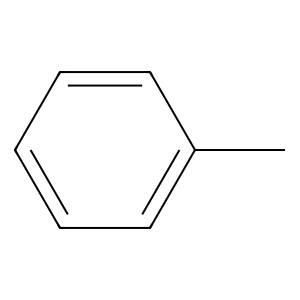

In [ ]:
img = Draw.MolToImage(m)
img

## **Calculate Lipinski Descriptors**
Christopher Lipinski, a scientist at Pfizer, came up with a set of rule-of-thumb for evaluating the **druglikeness** of compounds. Such druglikeness is based on the Absorption, Distribution, Metabolism and Excretion (ADME) that is also known as the pharmacokinetic profile. Lipinski analyzed all orally active FDA-approved drugs in the formulation of what is to be known as the **Rule-of-Five** or **Lipinski's Rule**.

The Lipinski's Rule stated the following:
* Molecular weight < 500 Dalton
* Octanol-water partition coefficient (LogP) < 5
* Hydrogen bond donors < 5
* Hydrogen bond acceptors < 10

In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

In [ ]:
# Inspired by: https://codeocean.com/explore/capsules?query=tag:data-curation
def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem)
        moldata.append(mol)

    baseData= np.arange(1,1)
    i=0
    for mol in moldata:

        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])

        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1

    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)

    return descriptors

In [ ]:
df_lipinski = lipinski(df_clean_smiles.canonical_smiles)
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,312.325,2.80320,0.0,5.0
1,376.913,4.55460,0.0,4.0
2,426.851,5.35740,0.0,4.0
3,404.845,4.70690,0.0,4.0
4,346.334,3.09530,0.0,5.0
...,...,...,...,...
8326,449.295,7.04910,0.0,2.0
8327,356.816,2.94110,3.0,5.0
8328,414.465,3.03242,3.0,6.0
8329,415.324,4.65730,2.0,4.0


## **Combine DataFrames**

Let's take a look at the 2 DataFrames that will be combined.

In [ ]:
df_combined = pd.concat([df,df_lipinski], axis=1)
df_combined

,molecule_chembl_id,canonical_smiles,standard_value,class,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,750.00,active,312.325,2.80320,0.0,5.0
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,100.00,active,376.913,4.55460,0.0,4.0
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,50000.00,inactive,426.851,5.35740,0.0,4.0
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,300.00,active,404.845,4.70690,0.0,4.0
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,800.00,active,346.334,3.09530,0.0,5.0
...,...,...,...,...,...,...,...,...
8326,CHEMBL6190210,FC(F)(F)c1cccc(-c2cc(-c3cccs3)n(-c3ccc(Br)cc3)...,0.48,active,449.295,7.04910,0.0,2.0
8327,CHEMBL6192902,O=C(NNC(=S)Nc1ccccc1[N+](=O)[O-])c1sccc1Cl,400.00,active,356.816,2.94110,3.0,5.0
8328,CHEMBL6191782,Cc1cc(=O)[nH]c2c1C(=O)C(NCNc1c3c(nc4ccccc14)CC...,11.10,active,414.465,3.03242,3.0,6.0
8329,CHEMBL6190113,O=C(NCCCNc1c2c(nc3ccccc13)CCC2)c1cnc(Cl)c(Cl)c1,52.00,active,415.324,4.65730,2.0,4.0


## **Convert IC50 to pIC50**
To allow **IC50** data to be more uniformly distributed, we will convert **IC50** to the negative logarithmic scale which is essentially **-log10(IC50)**.

This custom function pIC50() will accept a DataFrame as input and will:
* Take the IC50 values from the ``standard_value`` column and converts it from nM to M by multiplying the value by 10$^{-9}$
* Take the molar value and apply -log10
* Delete the ``standard_value`` column and create a new ``pIC50`` column

In [ ]:
import numpy as np

def pIC50(input):
    pIC50 = []

    for i in input['standard_value_norm']:
        # Replace 0 with a small value to avoid log(0)
        if i == 0:
            i = 1e-10
        molar = i*(10**-9) # Converts nM to M
        pIC50.append(-np.log10(molar))

    input['pIC50'] = pIC50
    x = input.drop('standard_value_norm', axis=1)

    return x

Point to note: Values greater than 100,000,000 will be fixed at 100,000,000 otherwise the negative logarithmic value will become negative.

In [ ]:
df_combined.standard_value.describe()

,standard_value
count,7.146000e+03
mean,1.227757e+05
std,2.135648e+06
min,0.000000e+00
25%,1.580000e+02
50%,2.400000e+03
75%,1.639750e+04
max,1.636817e+08


In [ ]:
def norm_value(input):
    norm = []

    for i in input['standard_value']:
        if i > 100000000:
          i = 100000000
        norm.append(i)

    input['standard_value_norm'] = norm
    x = input.drop('standard_value', axis=1)

    return x

We will first apply the norm_value() function so that the values in the standard_value column is normalized.

In [ ]:
df_norm = norm_value(df_combined)
df_norm

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,standard_value_norm
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,active,312.325,2.80320,0.0,5.0,750.00
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,active,376.913,4.55460,0.0,4.0,100.00
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,inactive,426.851,5.35740,0.0,4.0,50000.00
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,active,404.845,4.70690,0.0,4.0,300.00
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,active,346.334,3.09530,0.0,5.0,800.00
...,...,...,...,...,...,...,...,...
8326,CHEMBL6190210,FC(F)(F)c1cccc(-c2cc(-c3cccs3)n(-c3ccc(Br)cc3)...,active,449.295,7.04910,0.0,2.0,0.48
8327,CHEMBL6192902,O=C(NNC(=S)Nc1ccccc1[N+](=O)[O-])c1sccc1Cl,active,356.816,2.94110,3.0,5.0,400.00
8328,CHEMBL6191782,Cc1cc(=O)[nH]c2c1C(=O)C(NCNc1c3c(nc4ccccc14)CC...,active,414.465,3.03242,3.0,6.0,11.10
8329,CHEMBL6190113,O=C(NCCCNc1c2c(nc3ccccc13)CCC2)c1cnc(Cl)c(Cl)c1,active,415.324,4.65730,2.0,4.0,52.00


In [ ]:
df_norm.standard_value_norm.describe()

,standard_value_norm
count,7.146000e+03
mean,1.138642e+05
std,1.487605e+06
min,0.000000e+00
25%,1.580000e+02
50%,2.400000e+03
75%,1.639750e+04
max,1.000000e+08


In [ ]:
df_final = pIC50(df_norm)
df_final

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,active,312.325,2.80320,0.0,5.0,6.124939
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,active,376.913,4.55460,0.0,4.0,7.000000
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,inactive,426.851,5.35740,0.0,4.0,4.301030
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,active,404.845,4.70690,0.0,4.0,6.522879
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,active,346.334,3.09530,0.0,5.0,6.096910
...,...,...,...,...,...,...,...,...
8326,CHEMBL6190210,FC(F)(F)c1cccc(-c2cc(-c3cccs3)n(-c3ccc(Br)cc3)...,active,449.295,7.04910,0.0,2.0,9.318759
8327,CHEMBL6192902,O=C(NNC(=S)Nc1ccccc1[N+](=O)[O-])c1sccc1Cl,active,356.816,2.94110,3.0,5.0,6.397940
8328,CHEMBL6191782,Cc1cc(=O)[nH]c2c1C(=O)C(NCNc1c3c(nc4ccccc14)CC...,active,414.465,3.03242,3.0,6.0,7.954677
8329,CHEMBL6190113,O=C(NCCCNc1c2c(nc3ccccc13)CCC2)c1cnc(Cl)c(Cl)c1,active,415.324,4.65730,2.0,4.0,7.283997


Let's write this to CSV file.

In [ ]:
df_final.to_csv('acetylcholinesterase_04_bioactivity_data_3class_pIC50.csv', index=False)

## **Removing the 'intermediate' bioactivity class**
Here, we will be removing the ``intermediate`` class from our data set.

In [ ]:
df_2class = df_final[df_final['class'] != 'intermediate']
df_2class

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,active,312.325,2.80320,0.0,5.0,6.124939
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,active,376.913,4.55460,0.0,4.0,7.000000
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,inactive,426.851,5.35740,0.0,4.0,4.301030
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,active,404.845,4.70690,0.0,4.0,6.522879
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,active,346.334,3.09530,0.0,5.0,6.096910
...,...,...,...,...,...,...,...,...
8326,CHEMBL6190210,FC(F)(F)c1cccc(-c2cc(-c3cccs3)n(-c3ccc(Br)cc3)...,active,449.295,7.04910,0.0,2.0,9.318759
8327,CHEMBL6192902,O=C(NNC(=S)Nc1ccccc1[N+](=O)[O-])c1sccc1Cl,active,356.816,2.94110,3.0,5.0,6.397940
8328,CHEMBL6191782,Cc1cc(=O)[nH]c2c1C(=O)C(NCNc1c3c(nc4ccccc14)CC...,active,414.465,3.03242,3.0,6.0,7.954677
8329,CHEMBL6190113,O=C(NCCCNc1c2c(nc3ccccc13)CCC2)c1cnc(Cl)c(Cl)c1,active,415.324,4.65730,2.0,4.0,7.283997


Let's write this to CSV file.

In [ ]:
df_2class.to_csv('acetylcholinesterase_05_bioactivity_data_2class_pIC50.csv', index=False)

## **Exploratory Data Analysis (Chemical Space Analysis) via Lipinski Descriptors**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='ticks')

In [ ]:
df_2class.head()

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,active,312.325,2.8032,0.0,5.0,6.124939
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,active,376.913,4.5546,0.0,4.0,7.000000
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,inactive,426.851,5.3574,0.0,4.0,4.301030
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,active,404.845,4.7069,0.0,4.0,6.522879
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,active,346.334,3.0953,0.0,5.0,6.096910


## **Frequency Plot of the 2 Bioactivity Classes**

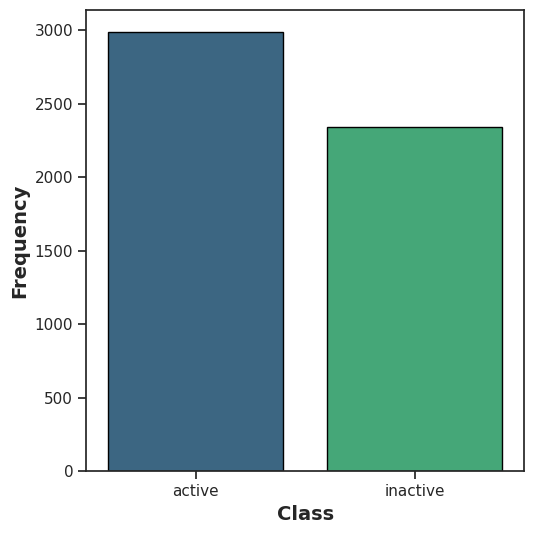

In [ ]:
# Frequency of the 2 bioactivity classes
plt.figure(figsize=(5.5, 5.5))
sns.countplot(x = 'class', data = df_2class, edgecolor='black', hue = "class", palette="viridis")
plt.xlabel("Class", fontsize = 14, fontweight="bold")
plt.ylabel("Frequency", fontsize = 14, fontweight="bold")
plt.tight_layout()
plt.savefig('plot_bioactivity_class.pdf')
plt.show()

## **Scatter Plot of MW versus LogP**

It can be seen that the 2 bioactivity classes are spanning similar chemical spaces as evident by the scatter plot of MW vs LogP.

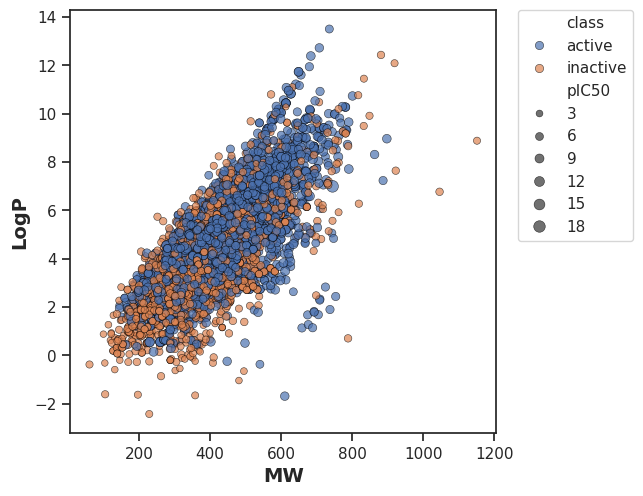

In [ ]:
plt.figure(figsize=(5.5, 5.5))
sns.scatterplot(x='MW', y='LogP', data=df_2class, hue='class', size='pIC50', edgecolor='black', alpha=0.7)
plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('plot_MW_vs_LogP.pdf')
plt.show()

## **Box Plots**

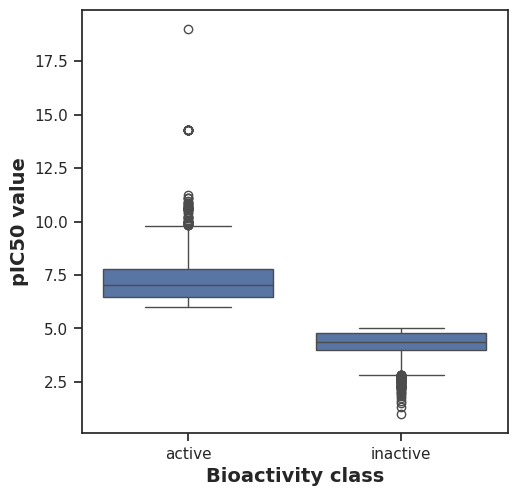

In [ ]:
# pIC50 value
plt.figure(figsize=(5.5, 5.5))
sns.boxplot(x = 'class', y = 'pIC50', data = df_2class)
plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')
plt.savefig('plot_ic50.pdf')
plt.show()

## **Statistical Analysis | Mann-Whitney U Test**

In [ ]:
def mannwhitney(descriptor, verbose=False):
  # https://machinelearningmastery.com/nonparametric-statistical-significance-tests-in-python/
  from numpy.random import seed
  from numpy.random import randn
  from scipy.stats import mannwhitneyu

# seed the random number generator
  seed(1)

# actives and inactives
  selection = [descriptor, 'class']
  df = df_2class[selection]

  active = df[df['class'] == 'active']
  active = active[descriptor]

  selection = [descriptor, 'class']
  df = df_2class[selection]
  inactive = df[df['class'] == 'inactive']
  inactive = inactive[descriptor]

# compare samples
  stat, p = mannwhitneyu(active, inactive)
  #print('Statistics=%.3f, p=%.3f' % (stat, p))

# interpret
  alpha = 0.05
  if p > alpha:
    interpretation = 'Same distribution (fail to reject H0)'
  else:
    interpretation = 'Different distribution (reject H0)'

  results = pd.DataFrame({'Descriptor':descriptor,
                          'Statistics':stat,
                          'p':p,
                          'alpha':alpha,
                          'Interpretation':interpretation}, index=[0])
  filename = 'mannwhitneyu_' + descriptor + '.csv'
  results.to_csv(filename)

  return results

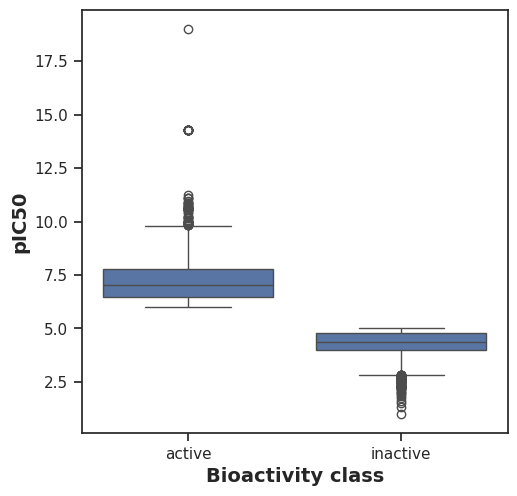

In [ ]:
# pIC50
plt.figure(figsize=(5.5, 5.5))
sns.boxplot(x = 'class', y = 'pIC50', data = df_2class)
plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50', fontsize=14, fontweight='bold')
plt.savefig('plot_pIC50.pdf')
plt.show()

In [ ]:
mannwhitney('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,7009205.0,0.0,0.05,Different distribution (reject H0)


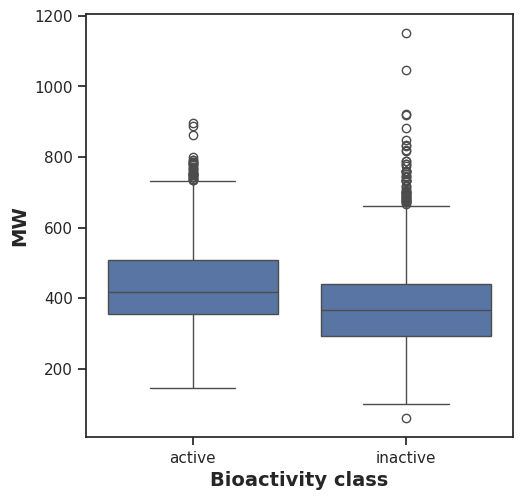

In [ ]:
# MW
plt.figure(figsize=(5.5, 5.5))
sns.boxplot(x = 'class', y = 'MW', data = df_2class)
plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')
plt.savefig('plot_MW.pdf')
plt.show()

In [ ]:
mannwhitney('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,4498949.0,5.645690e-71,0.05,Different distribution (reject H0)


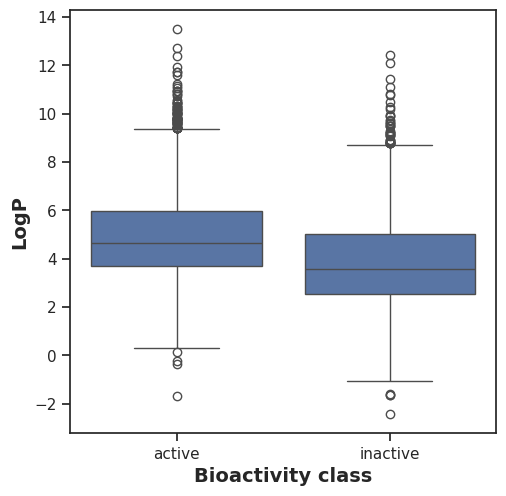

In [ ]:
# LogP
plt.figure(figsize=(5.5, 5.5))
sns.boxplot(x = 'class', y = 'LogP', data = df_2class)
plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.savefig('plot_LogP.pdf')
plt.show()

In [ ]:
mannwhitney('LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,4638380.5,1.042119e-91,0.05,Different distribution (reject H0)


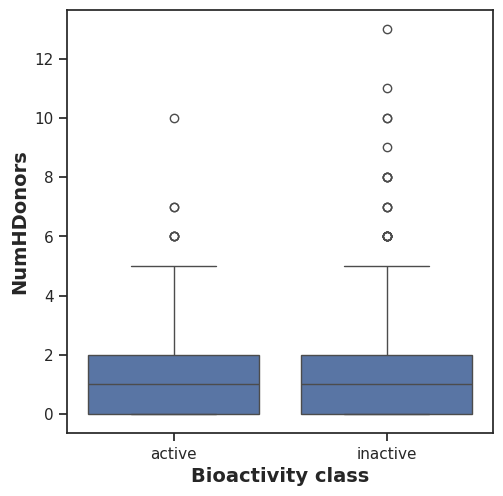

In [ ]:
# Num Hydrogen Donors
plt.figure(figsize=(5.5, 5.5))
sns.boxplot(x = 'class', y = 'NumHDonors', data = df_2class)
plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')
plt.savefig('plot_NumHDonors.pdf')
plt.show()

In [ ]:
mannwhitney('NumHDonors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,3889768.5,4.935151e-13,0.05,Different distribution (reject H0)


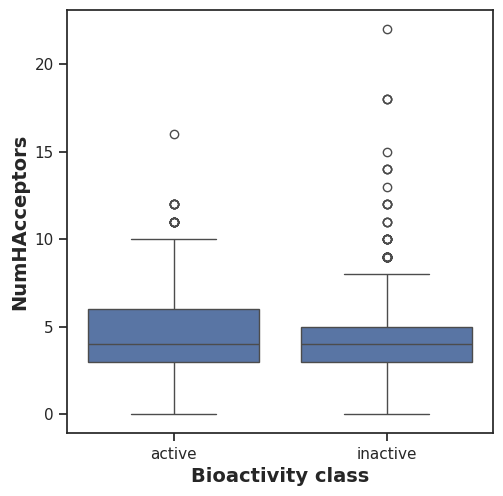

In [ ]:
# NumHAcceptors
plt.figure(figsize=(5.5, 5.5))
sns.boxplot(x = 'class', y = 'NumHAcceptors', data = df_2class)
plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')
plt.savefig('plot_NumHAcceptors.pdf')
plt.show()

In [ ]:
mannwhitney('NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,3770400.5,0.000001,0.05,Different distribution (reject H0)


#### **Interpretation of Statistical Results**
##### **Box Plots**

###### **pIC50 values**

Taking a look at pIC50 values, the **actives** and **inactives** displayed ***statistically significant difference***, which is to be expected since threshold values (``IC50 < 1,000 nM = Actives while IC50 > 10,000 nM = Inactives``, corresponding to ``pIC50 > 6 = Actives and pIC50 < 5 = Inactives``) were used to define actives and inactives.

###### **Lipinski's descriptors**

All of the 4 Lipinski's descriptors exhibited ***statistically significant difference*** between the **actives** and **inactives**.

In [ ]:
!ls

acetylcholinesterase_01_bioactivity_data_raw.csv
acetylcholinesterase_02_bioactivity_data_preprocessed.csv
acetylcholinesterase_03_bioactivity_data_curated.csv
acetylcholinesterase_04_bioactivity_data_3class_pIC50.csv
acetylcholinesterase_05_bioactivity_data_2class_pIC50.csv
mannwhitneyu_LogP.csv
mannwhitneyu_MW.csv
mannwhitneyu_NumHAcceptors.csv
mannwhitneyu_NumHDonors.csv
mannwhitneyu_pIC50.csv
plot_bioactivity_class.pdf
plot_ic50.pdf
plot_LogP.pdf
plot_MW.pdf
plot_MW_vs_LogP.pdf
plot_NumHAcceptors.pdf
plot_NumHDonors.pdf
plot_pIC50.pdf
sample_data


# **Part 4: Regression Concepts**

## Independent and Dependent Variable

- **Independent Variable**: A variable which value does not change by the effect of other variables and is used to manipulate the dependent variable. It often denoted as $X$.

- **Dependent Variable**: A variable whose value change when there is any manipulation in the values of independent variable. It is often denoted as $Y$

**Example**: Salary depends on year of experience

- **Salary**: Dependent Variable
- **Year of experience**: Independent Variable

## Simple Linear Regression


## What is Linear Regression?
A statistical method that allows us to summarize and study relationships between two continuous (quantitative) variables.
- One variable, denoted $x$, is regarded as the **predictor**, **explanatory**, or **independent variable**.
- The other variable, $y$ denoted , is regarded as the **response**, **outcome**, or **dependent variable**.

In short, algorithms that learn how output($y$) depends on input($x$)
$$y = f(x)$$
The simplest form of $f$;
$y = mx + c$

---
## Simple Linear Regression Equation
The simplest form of a simple linear regression equation with one dependent and one independent variable is represented by:
$$y = mx +c$$

Where,
- $y$ = dependent variable
- $x$ = independent variable
- $m$ = slope of the line
- $c$ = coefficient of the line

$$ m = \frac{y_2 - y_1}{x_2 - x_1}$$


---
Calculating slope(m) of the line

$$
m = r \frac{S_y}{S_x}
$$

Where,
- m = slope of the line
- r = pearson's r correlation
- $S_y$ = standard deviation of y
- $S_x$ = standard deviation of the x

Calculating y-intercept coefficient(c) of the line
$$
c = \overline y - m \overline x
$$

Where,
- c = intercept(c) or coefficient of the line
- m = slope of the line
- $\overline y$ mean of y
- $\overline x$ mean of x

## Multiple Linear Regression


$$
y = m_1x_1 + m_2x_2 + m_3x_3 + \cdots + m_nx_n + c
$$

- $x_1, x_2, x_3$ = independent variables
- $y$ = dependent variable
- $m_1, m_2, m_3$ = slopes
- $c$ = coefficient

In [ ]:
x_and_y = [(0, 1), (1, 3), (2, 2), (3, 5), (4, 7), (5, 8), (6, 8), (7, 9), (8, 10), (9,12)]
x_and_y

[(0, 1),
 (1, 3),
 (2, 2),
 (3, 5),
 (4, 7),
 (5, 8),
 (6, 8),
 (7, 9),
 (8, 10),
 (9, 12)]

In [ ]:
data = pd.DataFrame(x_and_y, columns=['X', 'Y_true'])
data

,X,Y_true
0,0,1
1,1,3
2,2,2
3,3,5
4,4,7
5,5,8
6,6,8
7,7,9
8,8,10
9,9,12


## Calculating Slope(m) of the Line

$$
m = r \frac{S_y}{S_x}
$$

Where,
- m = slope of the line
- r = pearson's r correlation
- $S_y$ = standard deviation of y
- $S_x$ = standard deviation of the x

In [ ]:
# calculate pearson's r correlation
data['X'].corr(data['Y_true'])

np.float64(0.9759805523748861)

In [ ]:
# calculate the standard deviation of `x`
data['X'].std()

3.0276503540974917

In [ ]:
# calculate the standard deviation of `y`
data['Y_true'].std()

3.6285901761795403

In [ ]:
m = 0.97 * (3.6/3.02)
print(m)

1.1562913907284769


## Calculating y-intercept coefficient(c) of the line

$$
c = \overline y - m \overline x
$$

Where,
- c = intercept(c) or coefficient of the line
- m = slope of the line
- $\overline y$ mean of y
- $\overline x$ mean of x

In [ ]:
# calculate the mean of `y`
data['Y_true'].mean()

np.float64(6.5)

In [ ]:
# calculate the mean of `x`
data['X'].mean()

np.float64(4.5)

In [ ]:
c = 6.5 - m * 4.5
print(round(c, 2))

1.3


In [ ]:
data

,X,Y_true
0,0,1
1,1,3
2,2,2
3,3,5
4,4,7
5,5,8
6,6,8
7,7,9
8,8,10
9,9,12


In [ ]:
y_pred = m * 1 + c
print(y_pred)

2.452980132450331


In [ ]:
data['Y_pred'] = m * data['X'] + c
data

,X,Y_true,Y_pred
0,0,1,1.296689
1,1,3,2.452980
2,2,2,3.609272
3,3,5,4.765563
4,4,7,5.921854
5,5,8,7.078146
6,6,8,8.234437
7,7,9,9.390728
8,8,10,10.547020
9,9,12,11.703311


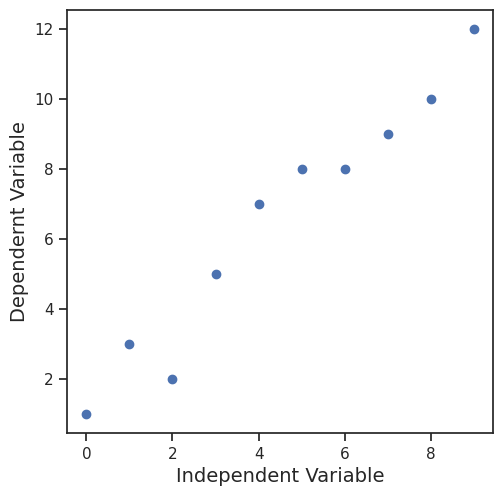

In [ ]:
plt.figure(figsize=(5.5, 5.5))
plt.scatter(data['X'], data['Y_true'])
plt.xlabel("Independent Variable", fontsize=14)
plt.ylabel("Dependernt Variable", fontsize=14)
plt.show()

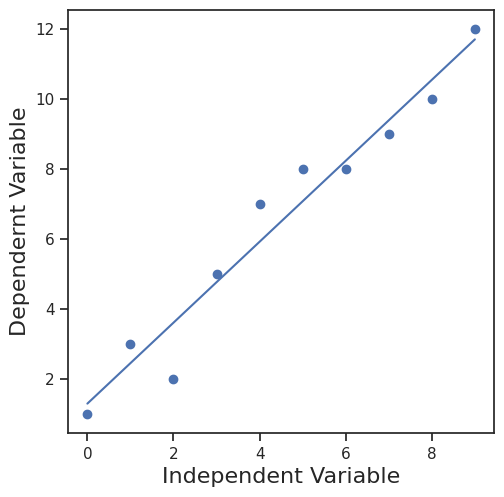

In [ ]:
plt.figure(figsize=(5.5, 5.5))

# actual values
plt.scatter(data['X'], data['Y_true'])

# prediction
plt.plot(data['X'], data['Y_pred'])

plt.xlabel("Independent Variable", fontsize=16)
plt.ylabel("Dependernt Variable", fontsize=16)
plt.show()

## Metrics for Evaluating Regression Model

### Calculate Errors

In [ ]:
data['errors'] = data['Y_true'] - data['Y_pred']
data

,X,Y_true,Y_pred,errors
0,0,1,1.296689,-0.296689
1,1,3,2.452980,0.547020
2,2,2,3.609272,-1.609272
3,3,5,4.765563,0.234437
4,4,7,5.921854,1.078146
5,5,8,7.078146,0.921854
6,6,8,8.234437,-0.234437
7,7,9,9.390728,-0.390728
8,8,10,10.547020,-0.547020
9,9,12,11.703311,0.296689


In [ ]:
# define true and predicted response values
true = data['Y_true']
pred = data['Y_pred']

### $R^2$ Score

In statistics, the coefficient of determination, denoted $R^2$ or $r^2$ and pronounced "R squared", is the proportion of the variation in the dependent variable that is predictable from the independent variable.

$$
R^2 = \frac{1 - SSR}{SST}
$$

Where,
- $R^2$ = coefficient of determination
- SSR = sum of square of residuals(errors)
- SST = total sum of squares

$$
SST = \frac{\overline y_t}{\sigma}
$$

- $y_t$ = actual value
- $\sigma$ = standard deviations

### Key Points
---
- The most common and popular metric for evaluating regression
- Between 0 and 100%
- Unfortunately, always increases by adding new x variables
- Can lead to overfitting
- Adjusted R2 preferred for evaluating multiple regression

### Adjusted-$R^2$
---
- Adjusted-$R^2$ = $R^2$ x (Penalty for adding irrelevant variables)
- Increases if irrelevant* variables are deleted
- (*irrelevant variables = any group whose F-ratio < 1)
- **Higher values** indicate a better fitting model, but adjusted R² can decrease if unnecessary predictors are added to the model.


### Interpretation
---
- $r^2$ > 0.9; Good model
- $r^2$ = 1.0; Perfect model, it means zero error(SSR = 0)
- $r^2$ > 0.5; Bad model; mean model(SSR = SST)
- $r^2$ < 0; SSR > SST  

In [ ]:
# calculate MAE using scikit-learn
from sklearn import metrics
print(metrics.r2_score(true, pred))

0.9524129243720711


### Absolute Error

$$\lvert y_t - y_p \rvert$$

Where,
- $y_t$ = true value of y
- $y_p$ = predicted value of y

In [ ]:
data

,X,Y_true,Y_pred,errors
0,0,1,1.296689,-0.296689
1,1,3,2.452980,0.547020
2,2,2,3.609272,-1.609272
3,3,5,4.765563,0.234437
4,4,7,5.921854,1.078146
5,5,8,7.078146,0.921854
6,6,8,8.234437,-0.234437
7,7,9,9.390728,-0.390728
8,8,10,10.547020,-0.547020
9,9,12,11.703311,0.296689


In [ ]:
np.abs(data['errors']).mean()

np.float64(0.6156291390728477)

### Mean Absolute Error(MAE)

- MAE represents the average absolute difference between the observed and predicted values.
- **Smaller MAE values** indicate better model performance.
- It gives an equal weight to all errors and does not square them, which makes it more robust to outliers compared to MSE.


**Mean Absolute Error** (MAE) is the mean of the absolute value of the errors:

$$\frac 1n\sum_{i=1}^n|y_t- {y}_p|$$

In [ ]:
# calculate MAE using scikit-learn
from sklearn import metrics
print(metrics.mean_absolute_error(true, pred))

0.6156291390728477


### Mean Squared Error

- MSE represents the average of the squared differences between the actual and predicted values.
- **Smaller MSE values** indicate better model performance.
- It penalizes larger errors more heavily due to squaring the residuals.
- **Higher sensitivity to outliers** because of the squaring.

**Mean Squared Error** (MSE) is the mean of the squared errors:

$$\frac 1n\sum_{i=1}^n(y_t-{y}_p)^2$$

In [ ]:
# calculate MSE using scikit-learn
print(metrics.mean_squared_error(true, pred))

0.5639068461909564


### Root Mean Squared Error

- RMSE is the square root of the MSE, providing error values in the same units as the original data.
- **Smaller RMSE values** indicate better model performance.
- It is more sensitive to large errors compared to MAE, making it useful when large errors are undesirable.

**Root Mean Squared Error** (RMSE) is the square root of the mean of the squared errors:

$$\sqrt{\frac 1n\sum_{i=1}^n(y_t-{y}_p)^2}$$

In [ ]:
# calculate RMSE using scikit-learn
print(np.sqrt(metrics.mean_squared_error(true, pred)))

0.7509373117584159


Comparing these metrics:

- **MAE** is the easiest to understand, because it's the average error.
- **MSE** is more popular than MAE, because MSE "punishes" larger errors.
- **RMSE** is even more popular than MSE, because RMSE is interpretable in the "y" units.

# **Part 5: Building Regression Model for Bioactivity Data**

In [ ]:
# import the last preprocessed data
df = pd.read_csv('acetylcholinesterase_04_bioactivity_data_3class_pIC50.csv')
df.head()

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,active,312.325,2.8032,0.0,5.0,6.124939
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,active,376.913,4.5546,0.0,4.0,7.000000
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,inactive,426.851,5.3574,0.0,4.0,4.301030
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,active,404.845,4.7069,0.0,4.0,6.522879
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,active,346.334,3.0953,0.0,5.0,6.096910


In [ ]:
# check missing values
df.isnull().sum()

,0
molecule_chembl_id,0
canonical_smiles,0
class,0
MW,0
LogP,0
NumHDonors,0
NumHAcceptors,0
pIC50,1185


In [ ]:
# shape
df.shape

(8331, 8)

In [ ]:
# impute pIC50 with mean using machine learning
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
df['pIC50'] = imputer.fit_transform(df['pIC50'].values.reshape(-1, 1))
df.head()

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,active,312.325,2.8032,0.0,5.0,6.124939
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,active,376.913,4.5546,0.0,4.0,7.000000
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,inactive,426.851,5.3574,0.0,4.0,4.301030
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,active,404.845,4.7069,0.0,4.0,6.522879
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,active,346.334,3.0953,0.0,5.0,6.096910


In [ ]:
df.isnull().sum()

,0
molecule_chembl_id,0
canonical_smiles,0
class,0
MW,0
LogP,0
NumHDonors,0
NumHAcceptors,0
pIC50,0


In [ ]:
# shape
df.shape

(8331, 8)

## **Input Features**
The ***Acetylcholinesterase*** data set contains 6898 input features and 1 output variable (pIC50 values).

In [ ]:
X = df.drop('pIC50', axis=1)
X

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,active,312.325,2.80320,0.0,5.0
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,active,376.913,4.55460,0.0,4.0
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,inactive,426.851,5.35740,0.0,4.0
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,active,404.845,4.70690,0.0,4.0
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,active,346.334,3.09530,0.0,5.0
...,...,...,...,...,...,...,...
8326,CHEMBL6190210,FC(F)(F)c1cccc(-c2cc(-c3cccs3)n(-c3ccc(Br)cc3)...,active,449.295,7.04910,0.0,2.0
8327,CHEMBL6192902,O=C(NNC(=S)Nc1ccccc1[N+](=O)[O-])c1sccc1Cl,active,356.816,2.94110,3.0,5.0
8328,CHEMBL6191782,Cc1cc(=O)[nH]c2c1C(=O)C(NCNc1c3c(nc4ccccc14)CC...,active,414.465,3.03242,3.0,6.0
8329,CHEMBL6190113,O=C(NCCCNc1c2c(nc3ccccc13)CCC2)c1cnc(Cl)c(Cl)c1,active,415.324,4.65730,2.0,4.0


## **Output Features**

In [ ]:
y = df.pIC50
y

,pIC50
0,6.124939
1,7.000000
2,4.301030
3,6.522879
4,6.096910
...,...
8326,9.318759
8327,6.397940
8328,7.954677
8329,7.283997


In [ ]:
# dimension
X.shape, y.shape

((8331, 7), (8331,))

### **Remove low Variance Features**

In [ ]:
from sklearn.feature_selection import VarianceThreshold
selection = VarianceThreshold(threshold=(.8 * (1 - .8)))
X = X.drop(columns=['molecule_chembl_id', 'canonical_smiles', 'class'])
X = selection.fit_transform(X)

In [ ]:
X

array([[312.325  ,   2.8032 ,   0.     ,   5.     ],
       [376.913  ,   4.5546 ,   0.     ,   4.     ],
       [426.851  ,   5.3574 ,   0.     ,   4.     ],
       ...,
       [414.465  ,   3.03242,   3.     ,   6.     ],
       [415.324  ,   4.6573 ,   2.     ,   4.     ],
       [601.235  ,   6.736  ,   1.     ,   6.     ]])

## **Data Split (80/20 Ratio)**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6664, 4), (1667, 4), (6664,), (1667,))

## **Building a Regression Model using Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

RandomForestRegressor()

In [ ]:
# r2 score
r2 = rf.score(X_test, y_test)
r2

0.28896986782909384

In [ ]:
y_pred = rf.predict(X_test)
y_pred

array([6.69481041, 6.24300607, 4.97438307, ..., 6.23665919, 5.81916918,
       6.6543222 ])

In [ ]:
y_true = y
y_true[:5]

,pIC50
0,6.124939
1,7.000000
2,4.301030
3,6.522879
4,6.096910


## **Scatter Plot of Experimental vs Predicted pIC50 Values**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(color_codes=True)
sns.set_style("white")

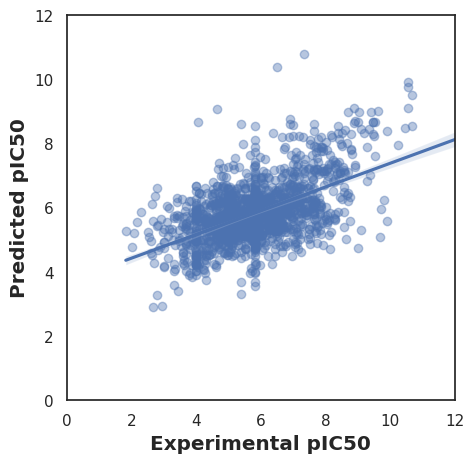

In [ ]:
ax = sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.4})
ax.set_xlabel('Experimental pIC50', fontsize='large', fontweight='bold')
ax.set_ylabel('Predicted pIC50', fontsize='large', fontweight='bold')
ax.set_xlim(0, 12)
ax.set_ylim(0, 12)
ax.figure.set_size_inches(5, 5)
plt.savefig('Experimental_vs_Predicted_pIC50_Values.pdf')
plt.show()

In [ ]:
!ls -l

total 10104
-rw-r--r-- 1 root root 6120086 Sep 18 02:18 acetylcholinesterase_01_bioactivity_data_raw.csv
-rw-r--r-- 1 root root  603399 Sep 18 02:18 acetylcholinesterase_02_bioactivity_data_preprocessed.csv
-rw-r--r-- 1 root root  684343 Sep 18 02:18 acetylcholinesterase_03_bioactivity_data_curated.csv
-rw-r--r-- 1 root root 1108425 Sep 18 02:19 acetylcholinesterase_04_bioactivity_data_3class_pIC50.csv
-rw-r--r-- 1 root root  713529 Sep 18 02:19 acetylcholinesterase_05_bioactivity_data_2class_pIC50.csv
-rw-r--r-- 1 root root   40997 Sep 18 02:19 Experimental_vs_Predicted_pIC50_Values.pdf
-rw-r--r-- 1 root root     126 Sep 18 02:19 mannwhitneyu_LogP.csv
-rw-r--r-- 1 root root     124 Sep 18 02:19 mannwhitneyu_MW.csv
-rw-r--r-- 1 root root     133 Sep 18 02:19 mannwhitneyu_NumHAcceptors.csv
-rw-r--r-- 1 root root     129 Sep 18 02:19 mannwhitneyu_NumHDonors.csv
-rw-r--r-- 1 root root     108 Sep 18 02:19 mannwhitneyu_pIC50.csv
-rw-r--r-- 1 root root   12666 Sep 18 02:19 plot_bioactivity_

In [ ]:
# Download all the files as zip
!zip -r ai4dd.zip . -i *.csv *.pdf

  adding: mannwhitneyu_NumHAcceptors.csv (deflated 11%)
  adding: mannwhitneyu_MW.csv (deflated 10%)
  adding: plot_MW.pdf (deflated 38%)
  adding: plot_NumHDonors.pdf (deflated 38%)
  adding: plot_NumHAcceptors.pdf (deflated 39%)
  adding: plot_LogP.pdf (deflated 37%)
  adding: acetylcholinesterase_05_bioactivity_data_2class_pIC50.csv (deflated 76%)
  adding: plot_pIC50.pdf (deflated 37%)
  adding: acetylcholinesterase_01_bioactivity_data_raw.csv (deflated 92%)
  adding: acetylcholinesterase_02_bioactivity_data_preprocessed.csv (deflated 80%)
  adding: plot_ic50.pdf (deflated 36%)
  adding: mannwhitneyu_LogP.csv (deflated 9%)
  adding: mannwhitneyu_NumHDonors.csv (deflated 10%)
  adding: plot_MW_vs_LogP.pdf (deflated 2%)
  adding: acetylcholinesterase_03_bioactivity_data_curated.csv (deflated 81%)
  adding: acetylcholinesterase_04_bioactivity_data_3class_pIC50.csv (deflated 77%)
  adding: plot_bioactivity_class.pdf (deflated 37%)
  adding: mannwhitneyu_pIC50.csv (deflated 9%)
  adding